In [1]:
import spatialdata as sd
from spatialdata_plot import pl
import pandas as pd
import warnings
import matplotlib.patches as mpatches

from matplotlib.colors import LinearSegmentedColormap

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import joblib
from matplotlib.colors import Normalize

warnings.filterwarnings('ignore')

transparent_to_red_cmap = LinearSegmentedColormap.from_list('transparent_to_red', 
                                    [(1, 1, 1, 0), (1, 0, 0, 1)], N=256)

/home/jmuhlich/development/Zhao-FMSAE-2026/.venv/lib/python3.14/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/jmuhlich/development/Zhao-FMSAE-2026/.venv/lib/python3.14/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


### Loading example dataset 

This example dataset is stored as a `spatialdata` object with one H&E whole slide image (downsampled) and pre-computed UNI foundation model embedding for image patches, as well as coordinates for these patches. This example image comes from DS4 (lung adenocarcinoma), which is different from DS1 (tuberculosis), so this notebook illustrates how the SAE extract generalizable features that can be used to annotate other tissue images.

Let's first pull the data online from Amazon S3 storage container.

In [2]:
sdata = sd.read_zarr('data/demo_dataset.zarr')


version mismatch: detected: RasterFormatV02, requested: FormatV04


We can make use of `spatialdata.plot` to visualize the whole slide image:

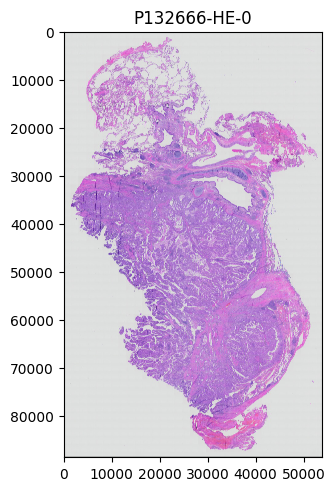

In [3]:
image_name = 'P132666-HE-0'
sdata.pl.render_images(element=image_name,
                        norm=Normalize(vmin=0, vmax=255))\
    .pl.show(image_name)

### Applying pre-trained sparse autoencoder (SAE) to the dataset

For this demo, we also provided the SAE model pre-trained on ~2M patches from DS1. Let's download the model and then apply it to the UNI embedding stored in the `spatialdata` dataset. The output of the SAE model is a compressed sparse matrix.

In [4]:
sae = joblib.load('data/ref_SAE_compressed.joblib')


In [5]:
patch_table = sdata[f'{image_name}_grid_point_patch']
sae_embeddings = sae.transform(patch_table.obsm['UNI_embedding'], device='cpu')
patch_table.var.index = pd.Index([f'UNI_SAE_{i}' for i in range(sae_embeddings.shape[1])])
patch_table.X = sae_embeddings
patch_table.X

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 114.32it/s]


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1065978 stored elements and shape (35894, 65536)>

We reported in the paper that feature F7815 is interpreted as airway epithelium on DS1. Let's plot make the feature map using `spatialdata-plot` and see what the feature looks like in LUAD. We see that it also detects airway epithelium.

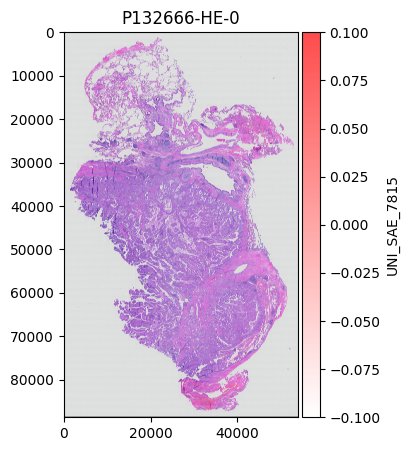

In [6]:
feature_idx = 7815
fig, ax = plt.subplots(figsize=(5, 5))
sdata.pl.render_images(element=image_name,
                        norm=Normalize(vmin=0, vmax=255))\
    .pl.render_shapes(element=f'{image_name}_grid_point_bbox', 
                      color=f'UNI_SAE_{feature_idx}',
                      cmap=transparent_to_red_cmap,
                      fill_alpha=0.7,
                      method='matplotlib',
                      datashader_reduction='max',
        )\
    .pl.show(image_name, ax=ax)

### Composing multi-feature map 

As shown in our study, after interpreting highly activate SAE features we can group them by aggregating normalized feature scores. Let's explore how multi-feature map showing different feature groups can extensively annotate the example image. First, we will load the mapping from feature IDs to group IDs and also from group IDs to histomorphology interpretations.

In [7]:
df_feature_groups = pd.read_csv('data/SAE_feature_groups.csv', index_col=0) 
df_group_names = pd.read_csv('data/SAE_group_names.csv', index_col=0) 

In [8]:
df_feature_groups.head()

,feature_idx,group,revised_group
0,26543,1,25
1,17932,1,25
2,49932,1,25
3,35699,1,25
4,40982,1,25


In [9]:
df_group_names.head()

,group_name
1,Pleura
2,Respiratory epithelium
3,Blood vessel intima/media
4,Blood vessel adventitia
5,Atelectatic lung parenchyma


Next, we compute the max score across the demo dataset for each feature to normalize the feature scores, and then aggregate scores in each feature group.

In [10]:
from utils import copy_feature_score_to_obs

feature_ids = df_feature_groups['feature_idx'].tolist()
max_scores = {feature: 0 for feature in feature_ids}

for feature in tqdm(feature_ids):
    copy_feature_score_to_obs(patch_table=patch_table,
                                    feature_name=f'UNI_SAE_{feature}')
    max_scores[feature] = max(max_scores[feature], patch_table.obs[f'UNI_SAE_{feature}'].max())

for feature in tqdm(feature_ids):
    scores = patch_table.obs[f'UNI_SAE_{feature}'].values
    patch_table.obs[f'UNI_SAE_{feature}'] = scores / max_scores[feature]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 361/361 [00:00<00:00, 13178.84it/s]


In [11]:
feature_groups = df_feature_groups['revised_group'].tolist()
n_groups = max(feature_groups)
for group in range(1,n_groups+1):
    feature_set = []
    for feature_idx in feature_ids:
        if feature_groups[feature_ids.index(feature_idx)] == group:
            feature_set.append(feature_idx)
        
    patch_table = sdata[f'{image_name}_grid_point_patch']
    aggregate_score = patch_table.obs[[f'UNI_SAE_{feature_idx}' \
                        for feature_idx in feature_set]].max(axis=1)
    patch_table.obs[f'SAE_group_{group}'] = aggregate_score

Finally, we will make a multi-feature map by first rasterizing the patches onto the WSI and then applying a different color to each layer.

In [12]:
selected_groups = [5,10,6,9,11,12,13,14,3,2,7,8,16,21,4,19,20]
vmins = [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
group_colors = [(0,1,0), (0,1,0), (0,1,0), (0,1,0), (0,1,0), 
                  (0,1,0), (0,1,0), (0,1,1), (1,0,0), (0,0,0), 
                  (0,0.4,0), (1,0,1), (0,0,1), (1,1,0), (1,0,0), 
                  (0.55, 0.27, 0.07), (0.55, 0.27, 0.07)]


group_cmaps = []
for color in group_colors:
    rgb = color[:3]
    cmap = LinearSegmentedColormap.from_list(
        'trans_to_color',
        [(1, 1, 1, 0), (*rgb, 0.8)],
        N=256
    )
    group_cmaps.append(cmap)


In [13]:
sdata[f'{image_name}']['scale0']['image']

<xarray.DataArray 'image' (c: 3, y: 5542, x: 3371)> Size: 56MB
dask.array<from-zarr, shape=(3, 5542, 3371), dtype=uint8, chunksize=(3, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U1 12B 'r' 'g' 'b'
  * y        (y) float64 44kB 0.5 1.5 2.5 3.5 ... 5.54e+03 5.54e+03 5.542e+03
  * x        (x) float64 27kB 0.5 1.5 2.5 3.5 ... 3.368e+03 3.37e+03 3.37e+03
Attributes:
    transform:  {'global': Sequence \n    Scale (c, y, x)\n        [ 1.      ...

In [15]:
from spatialdata import get_pyramid_levels

he_img = sdata[f'{image_name}']['scale0']['image'].compute().data
_, img_h, img_w = he_img.shape


In [16]:
from utils import interpolate_patch_max

ys = (patch_table.obs['ymin'].values + patch_table.obs['ymax'].values) / 2
xs = (patch_table.obs['xmin'].values + patch_table.obs['xmax'].values) / 2

interpolated_all = []
for group_id in tqdm(selected_groups):
    scores = patch_table.obs[f'SAE_group_{group_id}'].values.astype(float)
    samples = {
        (int(x), int(y)): scores[i]
        for i, (x, y) in enumerate(zip(xs, ys))
    }

    interpolated = interpolate_patch_max(
        samples=samples,
        height=img_h*16, # because WSI is downsampled by 16x
        width=img_w*16,
        downsample=16,
        patch_size=448 
    )
    interpolated_all.append(interpolated)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:01<00:00, 10.76it/s]


(np.float64(-0.5),
 np.float64(3370.5),
 np.float64(5541.5),
 np.float64(-0.5))

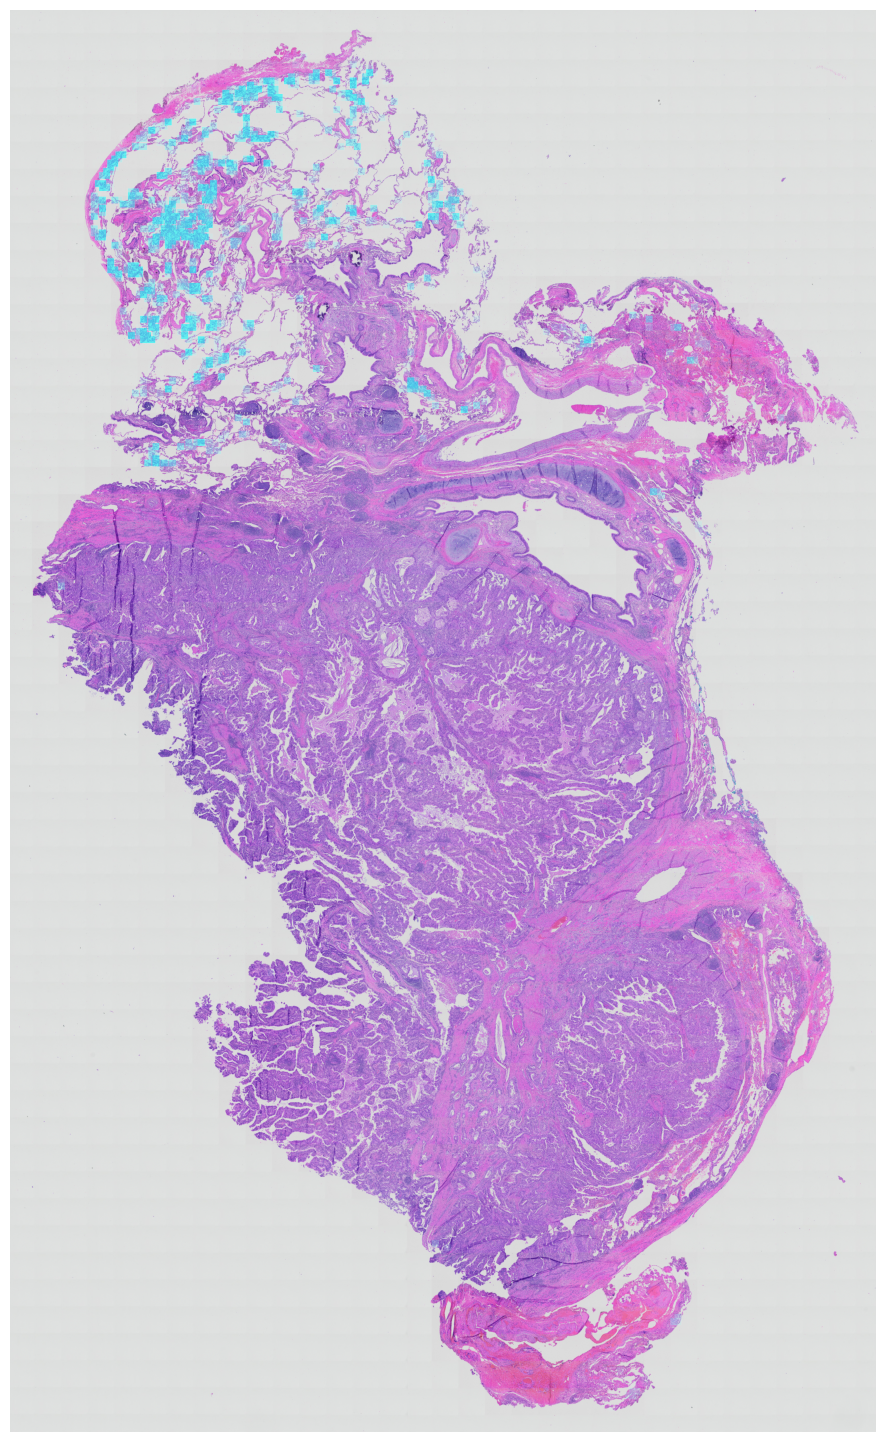

In [17]:
he_rgb = np.moveaxis(he_img, 0, -1) 
he_rgb = np.clip(he_rgb / 255.0, 0, 1)

fig, ax = plt.subplots(figsize=(img_w / 300, img_h / 300))
ax.imshow(he_rgb)
for i, cmap in enumerate(group_cmaps):
    interpolated = interpolated_all[i]  # (out_H, out_W)
    interpolated = interpolated / interpolated.max()
    ax.imshow(interpolated, cmap=cmap, origin='upper', 
              vmin=vmins[i], vmax=0.5, alpha=0.7) 
ax.axis('off')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

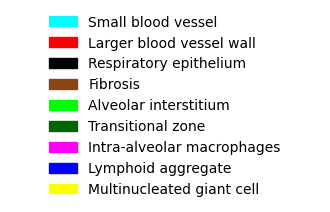

In [17]:
import matplotlib.patches as mpatches

mfm_legend = [
    ((0,1,1), 'Small blood vessel'),
    ((1,0,0), 'Larger blood vessel wall'),
    ((0,0,0), 'Respiratory epithelium'),
    ((0.55, 0.27, 0.07), 'Fibrosis'),
    ((0,1,0), 'Alveolar interstitium'),
    ((0,0.4,0), 'Transitional zone'),
    ((1,0,1), 'Intra-alveolar macrophages'),
    ((0,0,1), 'Lymphoid aggregate'),
    ((1,1,0), 'Multinucleated giant cell')
]
fig_patch = plt.figure(figsize=(4, 2))
patches = [mpatches.Patch(color=color, label=class_name) for (color, class_name) in mfm_legend]
plt.legend(handles=patches, loc='center', frameon=False, fontsize=10)
plt.axis('off')
